# EN3160 Assignment 1 on Intensity Transformations and Neighborhood Filtering

##### Index No: 230476T
##### Name: Perera G.M.B.

https://github.com/maneth-b03p/Image_Processing_and_Machine_Vision_Activities.git

In [38]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

Question 1

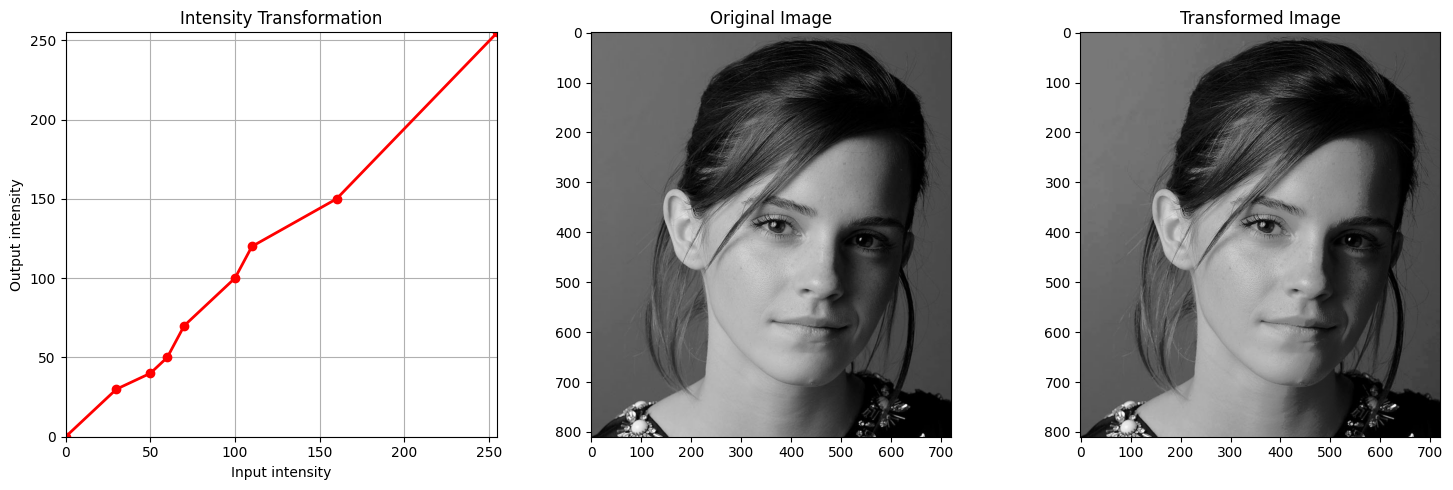

In [39]:
def intensity_transform(im, breakpoints):

    x_points = breakpoints[:, 0]
    y_points = breakpoints[:, 1]
    
    all_inputs = np.arange(256)
    lut = np.interp(all_inputs, x_points, y_points).astype(np.uint8)
    
    transformed_im = cv2.LUT(im, lut)
    
    return transformed_im

breakpoints_fig1a = np.array([
    [0, 0],
    [30, 30],
    [50, 40],
    [60, 50],  
    [70, 70], 
    [100, 100],
    [110, 120],
    [160, 150],
    [255, 255]
], dtype=np.float32)

img = cv2.imread('../images/images/q1.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


transformed_img = intensity_transform(img, breakpoints_fig1a)


fig, axes = plt.subplots(1, 3, figsize=(15, 5))


axes[0].plot(breakpoints_fig1a[:, 0], breakpoints_fig1a[:, 1], 'r-o', linewidth=2)
axes[0].set_title("Intensity Transformation")
axes[0].set_xlabel("Input intensity")
axes[0].set_ylabel("Output intensity")
axes[0].set_xlim([0, 255])
axes[0].set_ylim([0, 255])
axes[0].grid(True)

axes[1].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1].set_title("Original Image")

axes[2].imshow(transformed_img, cmap='gray', vmin=0, vmax=255)
axes[2].set_title("Transformed Image")

plt.tight_layout()
plt.show()

Question 2

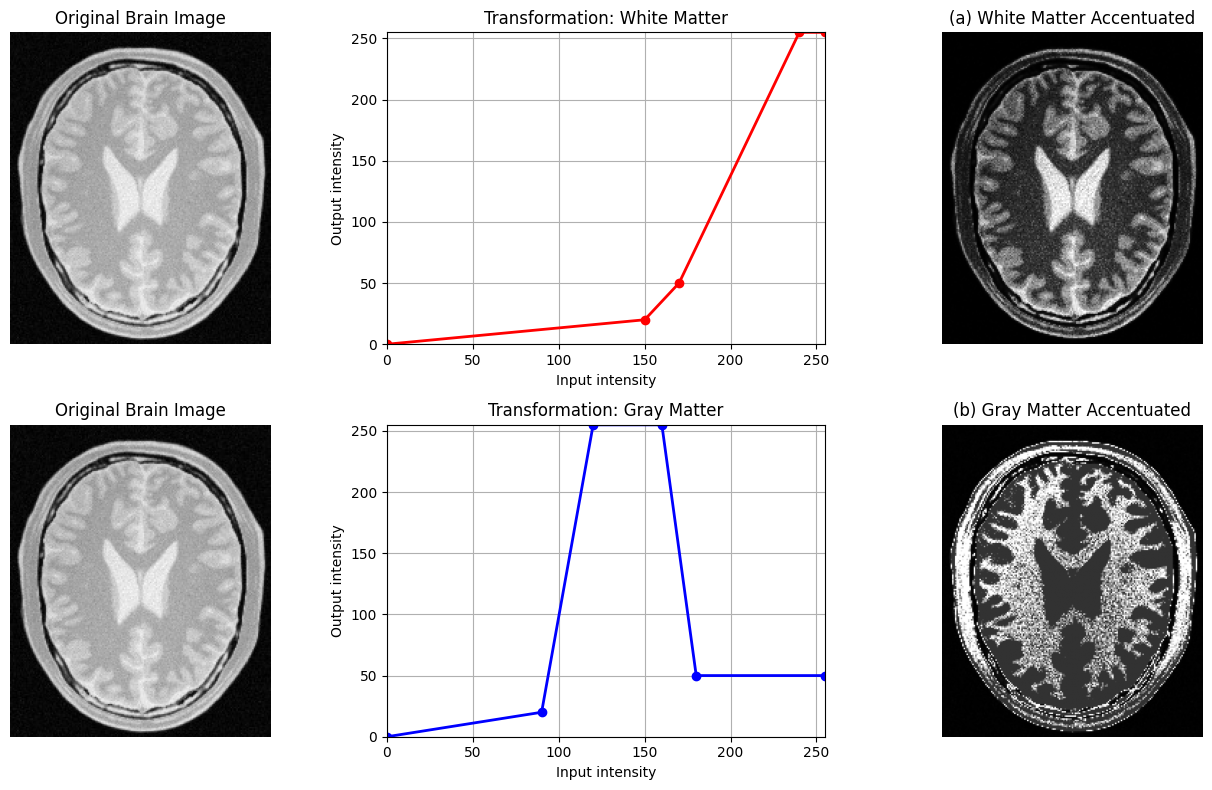

In [29]:
img = cv2.imread('../images/images/q2.jpeg', cv2.IMREAD_GRAYSCALE)

if img is None:
    img = np.random.randint(0, 256, (300, 300), dtype=np.uint8)


bp_white_matter = np.array([
    [0, 0],
    [150, 20],  
    [170, 50], 
    [240, 255],  
    [255, 255]
], dtype=np.float32)

bp_gray_matter = np.array([
    [0, 0],
    [90, 20],
    [120, 255], 
    [160, 255],
    [180, 50],   
    [255, 50]
], dtype=np.float32)

img_wm = intensity_transform(img, bp_white_matter)
img_gm = intensity_transform(img, bp_gray_matter)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Brain Image")
axes[0, 0].axis('off')

axes[0, 1].plot(bp_white_matter[:, 0], bp_white_matter[:, 1], 'r-o', linewidth=2)
axes[0, 1].set_title("Transformation: White Matter")
axes[0, 1].set_xlabel("Input intensity")
axes[0, 1].set_ylabel("Output intensity")
axes[0, 1].set_xlim([0, 255])
axes[0, 1].set_ylim([0, 255])
axes[0, 1].grid(True)

axes[0, 2].imshow(img_wm, cmap='gray', vmin=0, vmax=255)
axes[0, 2].set_title("(a) White Matter Accentuated")
axes[0, 2].axis('off')


axes[1, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[1, 0].set_title("Original Brain Image")
axes[1, 0].axis('off')

axes[1, 1].plot(bp_gray_matter[:, 0], bp_gray_matter[:, 1], 'b-o', linewidth=2)
axes[1, 1].set_title("Transformation: Gray Matter")
axes[1, 1].set_xlabel("Input intensity")
axes[1, 1].set_ylabel("Output intensity")
axes[1, 1].set_xlim([0, 255])
axes[1, 1].set_ylim([0, 255])
axes[1, 1].grid(True)

axes[1, 2].imshow(img_gm, cmap='gray', vmin=0, vmax=255)
axes[1, 2].set_title("(b) Gray Matter Accentuated")
axes[1, 2].axis('off')

plt.tight_layout()
plt.show()

White matter: White regions should be kept as it is and grey and black regions should be pulled to black. So the intensity transformation function should be very low for most of the input intensity range (eg:[0, 150]). Then it should ramp up.

Grey matter: Grey region (eg: [100:170]) should be highlighted, by pulling those intensities to pure white and pull extreme pixel values to low values.

Question 3

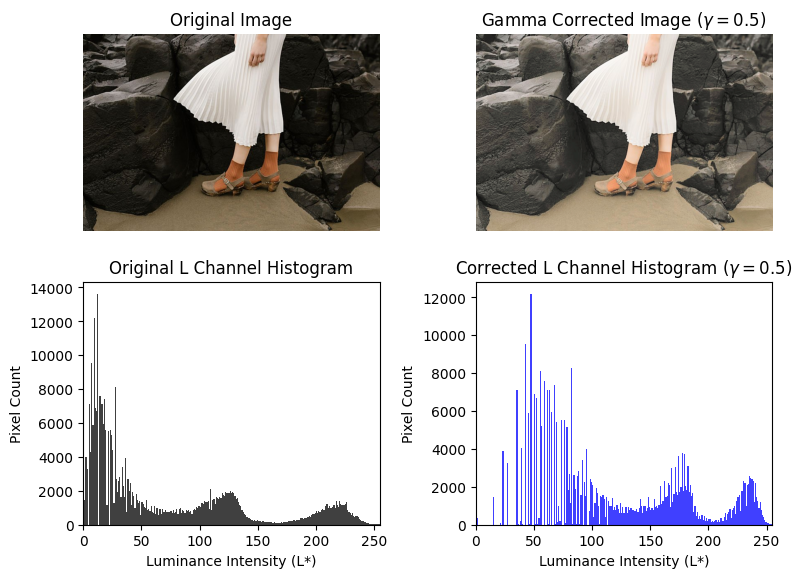

In [42]:
def apply_gamma_lab(image_path, gamma=0.5):
    bgr_img = cv2.imread(image_path)
    if bgr_img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
        
    rgb_orig = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    lab_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2LAB)
    
    L, a, b = cv2.split(lab_img)
    
    L_normalized = L / 255.0
    L_gamma = np.uint8(np.clip(np.power(L_normalized, gamma) * 255.0, 0, 255))

    lab_corrected = cv2.merge([L_gamma, a, b])

    bgr_corrected = cv2.cvtColor(lab_corrected, cv2.COLOR_LAB2BGR)
    rgb_corrected = cv2.cvtColor(bgr_corrected, cv2.COLOR_BGR2RGB)
    
    return rgb_orig, rgb_corrected, gamma

gamma_val = 0.5 
orig_img, corrected_img, gamma = apply_gamma_lab('../images/images/q3.jpeg', gamma=gamma_val)

lab_orig_L = cv2.cvtColor(cv2.cvtColor(orig_img, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2LAB)[:, :, 0]
lab_corr_L = cv2.cvtColor(cv2.cvtColor(corrected_img, cv2.COLOR_RGB2BGR), cv2.COLOR_BGR2LAB)[:, :, 0]


fig, axes = plt.subplots(2, 2, figsize=(8, 6))

axes[0, 0].imshow(orig_img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(corrected_img)
axes[0, 1].set_title(f"Gamma Corrected Image ($\gamma = {gamma}$)")
axes[0, 1].axis('off')

axes[1, 0].hist(lab_orig_L.ravel(), bins=256, range=[0, 256], color='black', alpha=0.75)
axes[1, 0].set_title("Original L Channel Histogram")
axes[1, 0].set_xlabel("Luminance Intensity (L*)")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])


axes[1, 1].hist(lab_corr_L.ravel(), bins=256, range=[0, 256], color='blue', alpha=0.75)
axes[1, 1].set_title(f"Corrected L Channel Histogram ($\gamma = {gamma}$)")
axes[1, 1].set_xlabel("Luminance Intensity (L*)")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])


plt.tight_layout()
plt.show()

To get the value of alpha, adjust it's value so the rock is clearly visible. Since the conversion is from dark to light, the alpha value should be less than 1.

Question 3

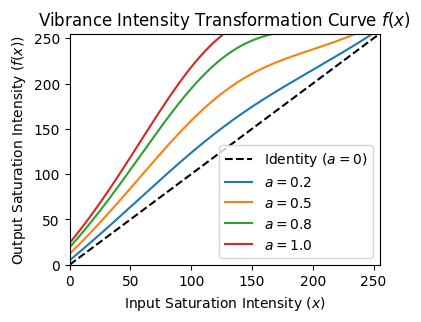

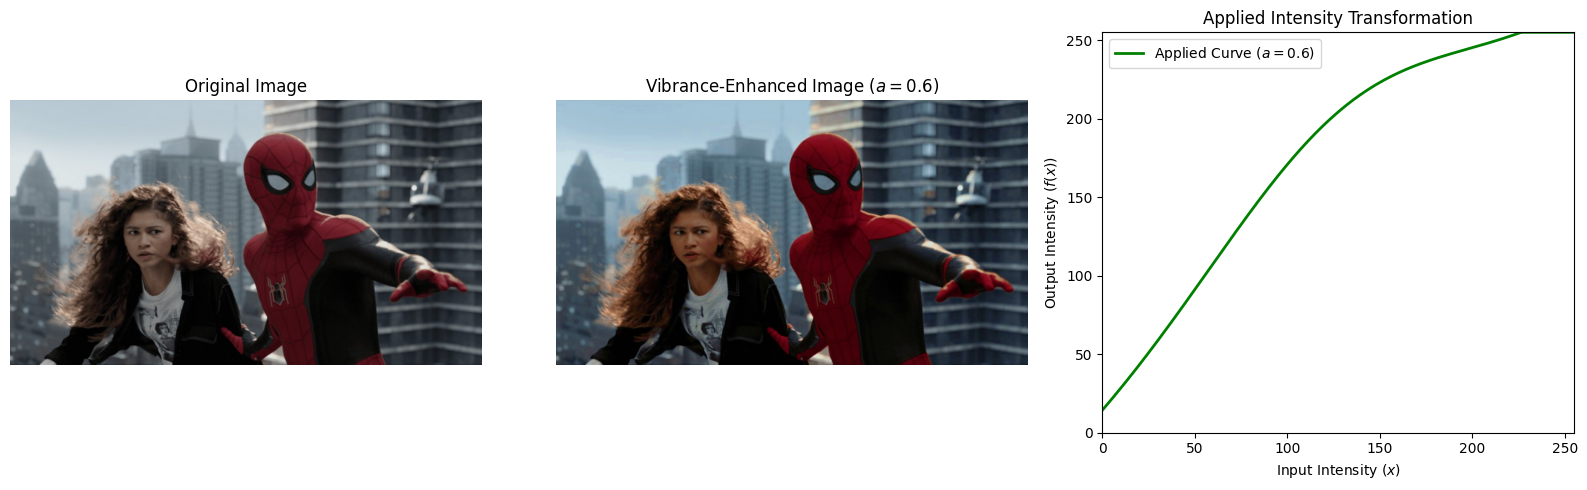

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

x = np.arange(0, 256, dtype=np.float32)
sigma = 70.0
a_values = [0.2, 0.5, 0.8, 1.0]

plt.figure(figsize=(4, 3))


plt.plot(x, x, 'k--', label="Identity ($a=0$)")


for a in a_values:
    fx = np.minimum(x + a * 128.0 * np.exp(-((x - 128.0) ** 2) / (2 * sigma ** 2)), 255.0)
    plt.plot(x, fx, label=f"$a = {a}$")

plt.title("Vibrance Intensity Transformation Curve $f(x)$")
plt.xlabel("Input Saturation Intensity ($x$)")
plt.ylabel("Output Saturation Intensity ($f(x)$)")
plt.xlim([0, 255])
plt.ylim([0, 255])
plt.legend()
plt.show()



def enhance_vibrance(image_path, a_param=0.5, sigma_param=70.0):
    bgr_img = cv2.imread(image_path)
    if bgr_img is None:
        raise FileNotFoundError(f"Image not found at path: {image_path}")
        
    rgb_orig = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    
    hsv_img = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv_img)
    
    x_lut = np.arange(0, 256, dtype=np.float32)
    lut_values = np.minimum(x_lut + a_param * 128.0 * np.exp(-((x_lut - 128.0) ** 2) / (2 * sigma_param ** 2)), 255.0)
    lut = lut_values.astype(np.uint8)
    
    s_enhanced = cv2.LUT(s, lut)
    
    hsv_enhanced = cv2.merge([h, s_enhanced, v])
    bgr_enhanced = cv2.cvtColor(hsv_enhanced, cv2.COLOR_HSV2BGR)
    rgb_enhanced = cv2.cvtColor(bgr_enhanced, cv2.COLOR_BGR2RGB)
    
    return rgb_orig, rgb_enhanced, x_lut, lut_values, a_param

a = 0.6
rgb_orig, rgb_enhanced, x_curve, y_curve, a_val = enhance_vibrance('../images/images/q4.jpeg', a_param=a)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

axes[0].imshow(rgb_orig)
axes[0].set_title("Original Image")
axes[0].axis('off')

axes[1].imshow(rgb_enhanced)
axes[1].set_title(f"Vibrance-Enhanced Image ($a = {a_val}$)")
axes[1].axis('off')

axes[2].plot(x_curve, y_curve, 'g-', linewidth=2, label=f"Applied Curve ($a={a_val}$)")
axes[2].set_title("Applied Intensity Transformation")
axes[2].set_xlabel("Input Intensity ($x$)")
axes[2].set_ylabel("Output Intensity ($f(x)$)")
axes[2].set_xlim([0, 255])
axes[2].set_ylim([0, 255])
axes[2].legend()

plt.tight_layout()
plt.show()

Increased the value of a until the image is vibrant enough.
A value like a=1 could be too high since most pixels will be saturated.

Question 5

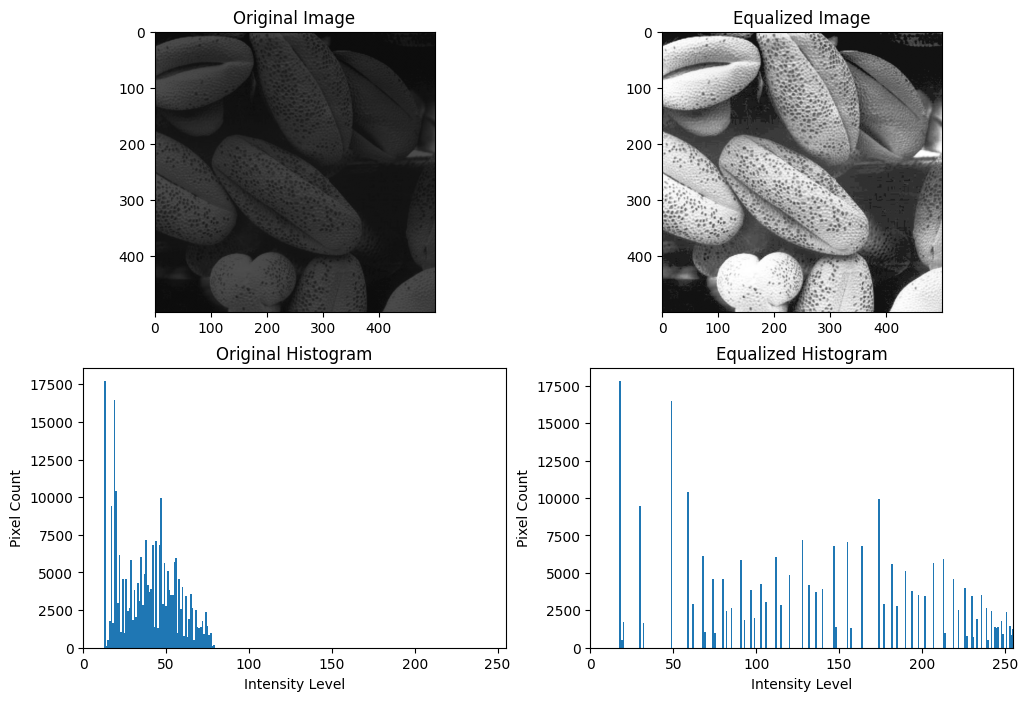

In [32]:
def histogram_equalization(image):
    M, N = image.shape
    pixels = M * N
    L = 256
    histogram_orig = np.zeros(L, dtype=int)
    for pixel_value in image.ravel():
        histogram_orig[pixel_value] += 1

    pmf = histogram_orig/pixels

    cdf = np.cumsum(pmf)

    lut = np.round((L - 1) * cdf).astype(np.uint8)
    equalized_img = lut[image]

    eq_hist = np.zeros(L, dtype=int)
    for pixel_value in equalized_img.ravel():
        eq_hist[pixel_value] += 1

    return equalized_img, histogram_orig, eq_hist


img = cv2.imread('../images/images/shells.tif', cv2.IMREAD_GRAYSCALE)
assert img is not None

img_eq, hist_orig, hist_eq = histogram_equalization(img)


fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img, cmap='gray', vmin=0, vmax=255)
axes[0, 0].set_title("Original Image")

axes[0, 1].imshow(img_eq, cmap='gray', vmin=0, vmax=255)
axes[0, 1].set_title("Equalized Image")

axes[1, 0].bar(range(256), hist_orig, width=1.0)
axes[1, 0].set_title("Original Histogram")
axes[1, 0].set_xlabel("Intensity Level")
axes[1, 0].set_ylabel("Pixel Count")
axes[1, 0].set_xlim([0, 255])

axes[1, 1].bar(range(256), hist_eq, width=1.0)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Intensity Level")
axes[1, 1].set_ylabel("Pixel Count")
axes[1, 1].set_xlim([0, 255])

plt.show()

The original image is dark, hence most pixels have low intensity value. By histogram equalization, all the intensity values are spreaded out in the full range.

Question 6

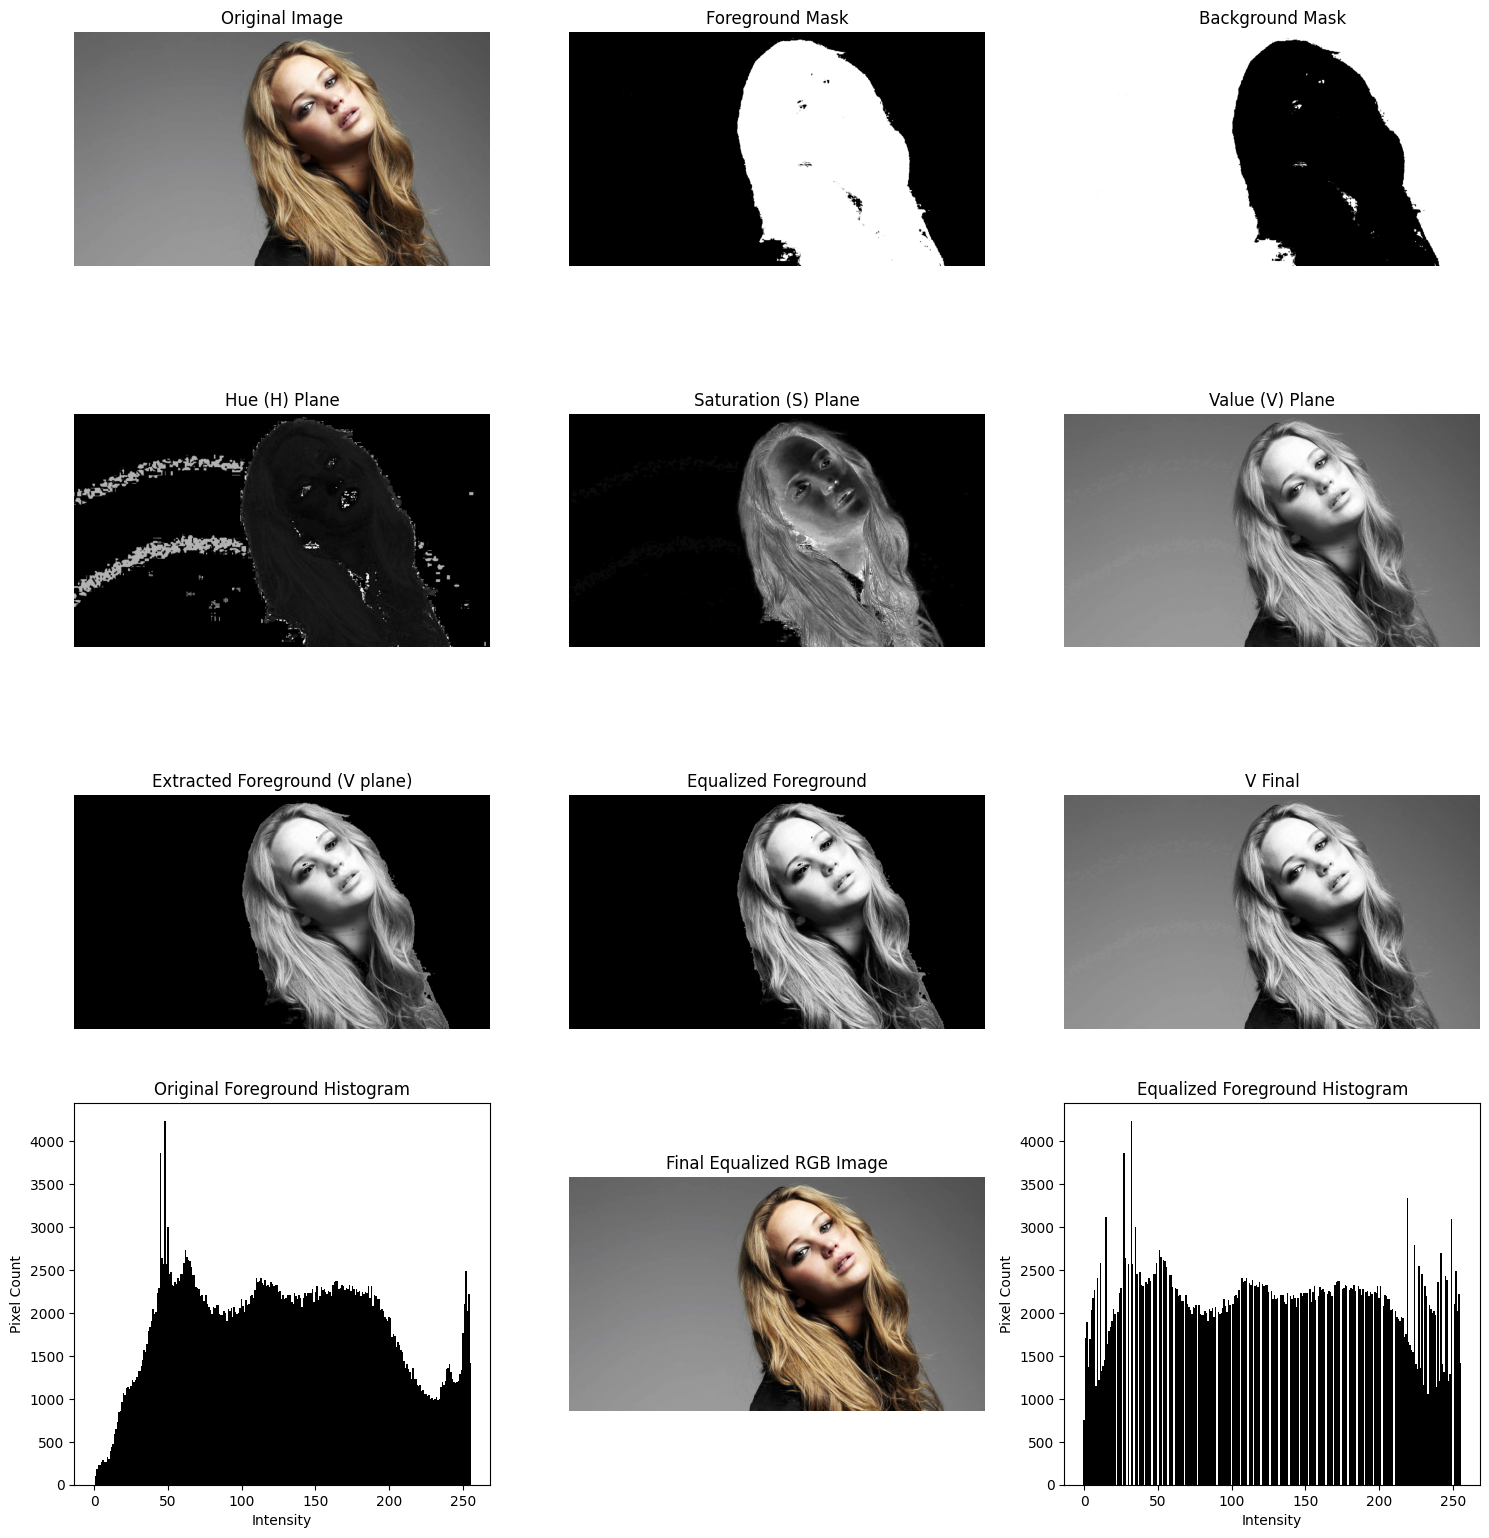

In [52]:
img = cv2.imread('../images/images/q6.jpeg')
assert img is not None

rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
hsv_img = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
H, S, V = cv2.split(hsv_img)

_, foreground_mask = cv2.threshold(S, 13, 255, cv2.THRESH_BINARY)

background_mask = cv2.bitwise_not(foreground_mask)


foreground = cv2.bitwise_and(V, V, mask=foreground_mask)


fg_pixels = foreground[foreground_mask > 0]
hist, bins = np.histogram(fg_pixels, bins=256, range = [0, 256])


cdf = hist.cumsum()

total_fg_pixels = len(fg_pixels)
L = 256
lut = np.round((L - 1) * cdf / total_fg_pixels).astype(np.uint8)

eq_fore = cv2.LUT(foreground, lut)
eq_fore = cv2.bitwise_and(eq_fore, eq_fore, mask=foreground_mask)

eq_fg_pixels = eq_fore[foreground_mask > 0]
hist1, bins = np.histogram(eq_fg_pixels, bins=256, range = [0, 256])

background_V = cv2.bitwise_and(V, V, mask=background_mask)
V_final = cv2.add(background_V, eq_fore)

hsv_final = cv2.merge([H, S, V_final])
result_rgb = cv2.cvtColor(cv2.cvtColor(hsv_final, cv2.COLOR_HSV2BGR), cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(4, 3, figsize=(15, 16))

axes[0, 0].imshow(rgb_img)
axes[0, 0].set_title("Original Image")
axes[0, 0].axis('off')

axes[0, 1].imshow(foreground_mask, cmap='gray')
axes[0, 1].set_title("Foreground Mask")
axes[0, 1].axis('off')

axes[0, 2].imshow(background_mask, cmap='gray')
axes[0, 2].set_title("Background Mask")
axes[0, 2].axis('off')


axes[1, 0].imshow(H, cmap='gray')
axes[1, 0].set_title("Hue (H) Plane")
axes[1, 0].axis('off')

axes[1, 1].imshow(S, cmap='gray')
axes[1, 1].set_title("Saturation (S) Plane")
axes[1, 1].axis('off')

axes[1, 2].imshow(V, cmap='gray')
axes[1, 2].set_title("Value (V) Plane")
axes[1, 2].axis('off')


axes[2, 0].imshow(foreground, cmap='gray')
axes[2, 0].set_title("Extracted Foreground (V plane)")
axes[2, 0].axis('off')

axes[2, 1].imshow(eq_fore, cmap='gray')
axes[2, 1].set_title("Equalized Foreground")
axes[2, 1].axis('off')

axes[2, 2].imshow(V_final, cmap='gray')
axes[2, 2].set_title("V Final")
axes[2, 2].axis('off')


axes[3, 0].bar(bins[:-1], hist, width=1.0, color='black')
axes[3, 0].set_title("Original Foreground Histogram")
axes[3, 0].set_xlabel("Intensity")
axes[3, 0].set_ylabel("Pixel Count")


axes[3, 1].imshow(result_rgb)
axes[3, 1].set_title("Final Equalized RGB Image")
axes[3, 1].axis('off')

axes[3, 2].bar(bins[:-1], hist1, width=1.0, color='black')
axes[3, 2].set_title("Equalized Foreground Histogram")
axes[3, 2].set_xlabel("Intensity")
axes[3, 2].set_ylabel("Pixel Count")

plt.tight_layout()
plt.show()

Saturation plane captures pure color information independent of brightness, making it robust against uneven lighting, highlights, and shadows. This clearly seen from the second row which displays the 3 planes.

Thresholding this plane yields a distinct binary mask (1 for target foreground, 0 for background) with sharp, well-defined boundaries.

With histogram eqalization on masked value plane, an enhanced foreground image is obtained.

Question 7

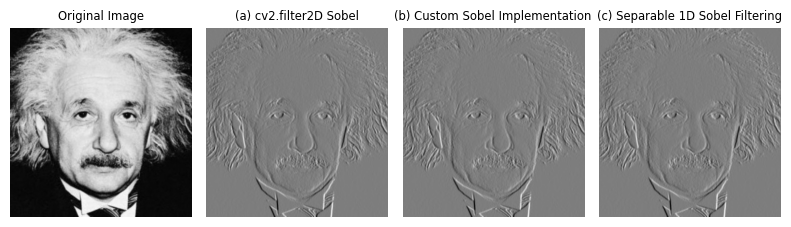

In [49]:
img = cv2.imread('../images/images/q7.jpeg', cv2.IMREAD_GRAYSCALE)
assert img is not None
img = img.astype(np.float64)

kernel_x = np.array([[1, 0, -1], [2, 0, -2], [1, 0, -1]])
filtered_a = cv2.filter2D(img, -1, kernel_x)

def custom_filter(image, kernel):
    h, w = image.shape
    kh, kw = kernel.shape
    pad_h = kh//2
    pad_w= kw//2

    padded_img = np.pad(image, ((pad_h, pad_h), (pad_w, pad_w)), mode='edge')
    output = np.zeros((h, w))
    
    for i in range(h):
        for j in range(w):
            region = padded_img[i:i + kh, j:j + kw]
            output[i, j] = np.sum(region * kernel)
            
    return output

filtered_b = custom_filter(img, kernel_x)

h_kernel = np.array([[1, 0, -1]])
v_kernel = np.array([[1],[2],[1]])

filtered_inter_c = cv2.filter2D(img, -1, h_kernel)
filtered_c = cv2.filter2D(filtered_inter_c, -1, v_kernel)

fig, axes = plt.subplots(1, 4, figsize=(8, 8))

axes[0].imshow(img, cmap='gray')
axes[0].set_title("Original Image", fontsize = "small")
axes[0].axis('off')

axes[1].imshow(filtered_a, cmap='gray')
axes[1].set_title("(a) cv2.filter2D Sobel", fontsize = "small")
axes[1].axis('off')

axes[2].imshow(filtered_b, cmap='gray')
axes[2].set_title("(b) Custom Sobel Implementation", fontsize = "small")
axes[2].axis('off')

axes[3].imshow(filtered_c, cmap='gray')
axes[3].set_title("(c) Separable 1D Sobel Filtering", fontsize = "small")
axes[3].axis('off')

plt.tight_layout()
plt.show()

In this edge detector, the images are computed as float values, since sobel filter contains negative values. Hence, fltered image gives 0 for plane areas (no edges) which corresponds to gray, since the pixel values are now signed. Black edge and white edge distinction in sobel-filtered image comes only when comparing the original image pixels transition is from dark to bright areas and bright to dark areas (negative gradient vs positive gradient). If the filtered image's absolute value is taken and displayed as unsigned numbers, the plane areas will be black and all edges will be white

Question 8

In [ ]:
def bilinear_interpolate_pixel(p00, p01, p10, p11, u, v):
    top = (1 - u) * p00 + u * p01
    bottom = (1 - u) * p10 + u * p11
    return (1 - v) * top + v * bottom

def zoom_image(img, s, method='bilinear'):
    if (s<=0 or s>10):
        return None
    h_orig, w_orig = img.shape[:2]

    h_new = int(round(s * (h_orig ) ))
    w_new = int(round(s * (w_orig ) ))
    
    if img.ndim == 3:
        out = np.zeros((h_new, w_new, img.shape[2]), dtype=np.float64)
    else:
        out = np.zeros((h_new, w_new), dtype=np.float64)
        
    img_float = img.astype(np.float64)

    if method == 'nearest':
        for r in range(h_new):
            y_orig = int(round(r / s))
            y_orig = min(max(y_orig, 0), h_orig - 1)
            
            for c in range(w_new):
                x_orig = int(round(c / s))
                x_orig = min(max(x_orig, 0), w_orig - 1)
                
                out[r, c] = img_float[y_orig, x_orig]

    elif method == 'bilinear':
        for r in range(h_new):
            y_continuous = r / s
            y0 = int(np.floor(y_continuous))
            y1 = min(y0 + 1, h_orig - 1)
            v = y_continuous - y0 
            
            for c in range(w_new):
                x_continuous = c / s
                x0 = int(np.floor(x_continuous))
                x1 = min(x0 + 1, w_orig - 1)
                u = x_continuous - x0 
                
                p00 = img_float[y0, x0]
                p01 = img_float[y0, x1]
                p10 = img_float[y1, x0]
                p11 = img_float[y1, x1]
                
                out[r, c] = bilinear_interpolate_pixel(p00, p01, p10, p11, u, v)
    return np.clip(out, 0, 255).astype(img.dtype)


def compute_ssd(img1, img2):
    if img1.shape != img2.shape:
        return None
    f1 = img1.astype(np.float64)
    f2 = img2.astype(np.float64)
    
    ssd = np.sum((f1 - f2) ** 2)
    norm_factor = np.sqrt(np.sum(f1 ** 2) * np.sum(f2 ** 2))
    return ssd / norm_factor


img_orig1 = cv2.imread('../images/images/im01.png')
img_small1 = cv2.imread('../images/images/im01small.png')

img_orig2 = cv2.imread('../images/images/im02.png')
img_small2 = cv2.imread('../images/images/im02small.png')

assert img_orig1 is not None and img_small1 is not None
assert img_orig2 is not None and img_small2 is not None

zoomed1_nn = zoom_image(img_small1, 4, method='nearest')
zoomed1_bl = zoom_image(img_small1, 4, method='bilinear')

zoomed2_nn = zoom_image(img_small2, 4, method='nearest')
zoomed2_bl = zoom_image(img_small2, 4, method='bilinear')

zoomed1_nn = zoomed1_nn[:img_orig1.shape[0], :img_orig1.shape[1]]
zoomed1_bl = zoomed1_bl[:img_orig1.shape[0], :img_orig1.shape[1]]

zoomed2_nn = zoomed2_nn[:img_orig2.shape[0], :img_orig2.shape[1]]
zoomed2_bl = zoomed2_bl[:img_orig2.shape[0], :img_orig2.shape[1]]

ssd1_nn = compute_ssd(img_orig1, zoomed1_nn)
ssd1_bl = compute_ssd(img_orig1, zoomed1_bl)

ssd2_nn = compute_ssd(img_orig2, zoomed2_nn)
ssd2_bl = compute_ssd(img_orig2, zoomed2_bl)

print(f"Image 1 Nearest SSD:  {ssd1_nn:.6f}")
print(f"Image 1 Bilinear SSD: {ssd1_bl:.6f}")
print(f"Image 2 Nearest SSD:  {ssd2_nn:.6f}")
print(f"Image 2 Bilinear SSD: {ssd2_bl:.6f}")


Image 1 Nearest SSD:  0.022724
Image 1 Bilinear SSD: 0.017942
Image 2 Nearest SSD:  0.010222
Image 2 Bilinear SSD: 0.007792


Bilinear interpolated zoom in gives lesser SSD than the nearest neighbour interpolated zoomed-in image, for both images.
So bilinear interpolated zoom-in has a higher accuracy in recovering details when zoomed in

Question 9

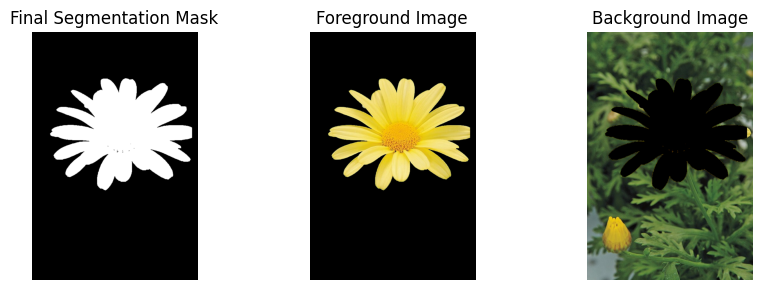

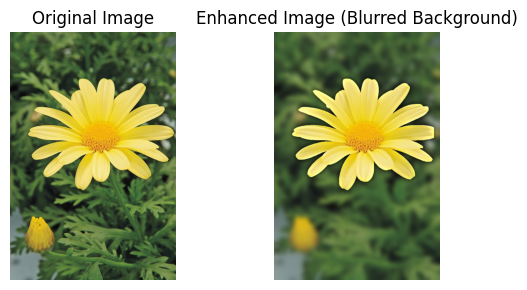

In [ ]:
img = cv2.imread('../images/images/q9.jpeg')

assert img is not None

img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

mask = np.zeros((h, w), np.uint8)
bgdModel = np.zeros((1, 65), np.float64)
fgdModel = np.zeros((1, 65), np.float64)

rect = (20, 20, w - 40, h - 300)
cv2.grabCut(img, mask, rect, bgdModel, fgdModel, 5, cv2.GC_INIT_WITH_RECT)

fg_mask = np.where((mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD), 1, 0).astype(np.uint8)
bg_mask = 1 - fg_mask

foreground = img_rgb * fg_mask[:, :, np.newaxis]
background = img_rgb * bg_mask[:, :, np.newaxis]

blurred_background = cv2.GaussianBlur(background, (51, 51), 0)
enhanced_img = cv2.add(foreground, blurred_background)


fig1, axes1 = plt.subplots(1, 3, figsize=(9, 3))

axes1[0].imshow(fg_mask * 255, cmap='gray')
axes1[0].set_title("Final Segmentation Mask", fontsize = "small")
axes1[0].axis('off')

axes1[1].imshow(foreground)
axes1[1].set_title("Foreground Image", fontsize = "small")
axes1[1].axis('off')

axes1[2].imshow(background)
axes1[2].set_title("Background Image", fontsize = "small")
axes1[2].axis('off')

plt.tight_layout()
plt.show()

fig2, axes2 = plt.subplots(1, 2, figsize=(6, 3))

axes2[0].imshow(img_rgb)
axes2[0].set_title("Original Image")
axes2[0].axis('off')

axes2[1].imshow(enhanced_img)
axes2[1].set_title("Enhanced Image (Blurred Background)", fontsize = "small")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


GrabCut algorithm is used for the segmentation by defining a bounding box
A strong gaussian kernel of 51x51 is used to blur the background heavily. Due to this, the edges of the flower in the background mask is slightly darker.

##### Answer to c) 
When the extracted background image is created, the foreground region is masked out with zero intensity (0 / black pixels). During the spatial convolution (blurring) process, the blur kernel near the object boundaries covers a spatial neighborhood that includes these adjacent zero-valued foreground pixels.

Because the kernel averages these pixel values together, the black 0 weights significantly reduce the weighted average of the neighboring background pixels, resulting in a dark boundary just outside the edge of the flower.

Question 10

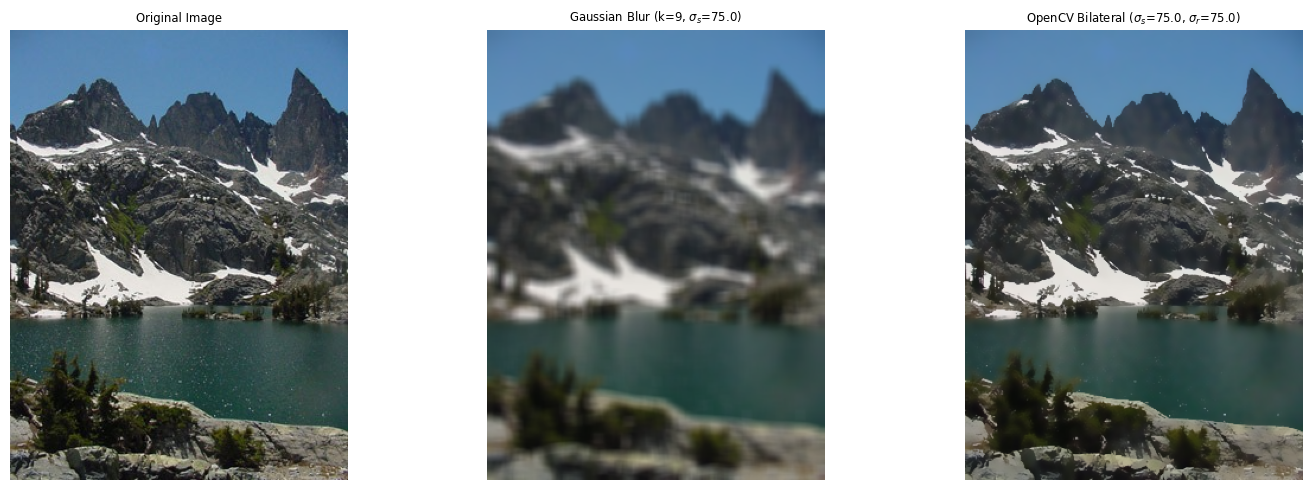

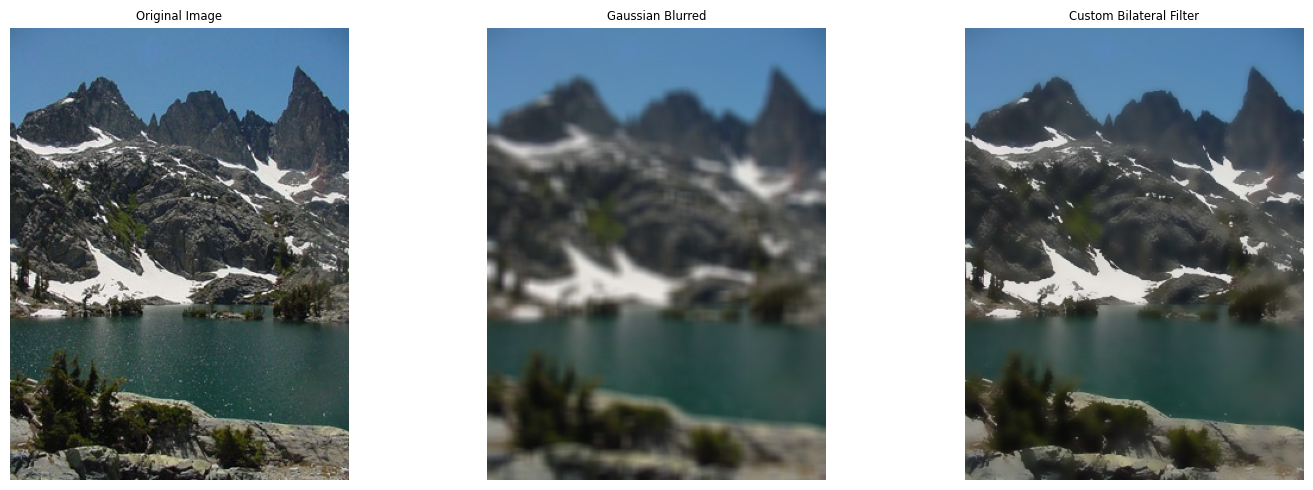

Normalized SSD between the two images: 2.996987e-03


In [50]:
img = cv2.imread('../images/images/q10.jpeg')

assert img is not None

img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

d = 9    
sigma_s = 75.0 
sigma_r = 75.0 

gaussian_img = cv2.GaussianBlur(img, (d, d), sigmaX=sigma_s, sigmaY=sigma_s)
cv_bilateral = cv2.bilateralFilter(img, d=d, sigmaColor=sigma_r, sigmaSpace=sigma_s)

fig1, axes1 = plt.subplots(1, 3, figsize=(15, 5))
axes1[0].imshow(img)
axes1[0].set_title("Original Image", fontsize = "small")
axes1[0].axis('off')

axes1[1].imshow(gaussian_img)
axes1[1].set_title(f"Gaussian Blur (k={d}, $\sigma_s$={sigma_s})", fontsize = "small")
axes1[1].axis('off')

axes1[2].imshow(cv_bilateral)
axes1[2].set_title(f"OpenCV Bilateral ($\sigma_s$={sigma_s}, $\sigma_r$={sigma_r})", fontsize = "small")
axes1[2].axis('off')

plt.tight_layout()
plt.show()



def custom_bilateral_filter(image, d, sigma_s, sigma_r):
    h, w = image.shape[:2]
    radius = d // 2


    padded = np.pad(image, ((radius, radius), (radius, radius), (0, 0)), mode='edge')

        
    padded = padded.astype(np.float64)
    img_float = image.astype(np.float64)
    output = np.zeros_like(img_float)


    y_grid, x_grid = np.mgrid[-radius:radius+1, -radius:radius+1]
    spatial_weights = np.exp(-(x_grid**2 + y_grid**2) / (2 * (sigma_s ** 2)))

    for r in range(h):
        for c in range(w):
            region = padded[r:r + d, c:c + d]
            center_val = img_float[r, c]

            
            diff = region - center_val
            intensity_dist_sq = np.sum(diff ** 2, axis=2)

            range_weights = np.exp(-intensity_dist_sq / (2 * (sigma_r ** 2)))
            total_weights = spatial_weights * range_weights
            w_p = np.sum(total_weights)
                     
            output[r, c] = np.sum(region * total_weights[:, :, np.newaxis], axis=(0, 1)) / w_p


    return np.clip(output, 0, 255).astype(image.dtype)


custom_bilateral = custom_bilateral_filter(img, d=d, sigma_s=sigma_s, sigma_r=sigma_r)

ssd = compute_ssd(custom_bilateral, cv_bilateral)

fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))
axes2[0].imshow(img)
axes2[0].set_title("Original Image", fontsize = "small")
axes2[0].axis('off')

axes2[1].imshow(gaussian_img)
axes2[1].set_title("Gaussian Blurred", fontsize = "small")
axes2[1].axis('off')

axes2[2].imshow(custom_bilateral)
axes2[2].set_title(f"Custom Bilateral Filter", fontsize = "small")
axes2[2].axis('off')

plt.tight_layout()
plt.show()

print(f"Normalized SSD between the two images: {ssd:.6e}")

The difference between the two bilateral filtered image is extremely small. So the custom bilateral filter is accurate enough
Bilateral filter correctly smooths surfaces while preserving the edges.